**Project Title:-** ***📱 App Market Analytics – Google Play Edition***

**1. Import All Libraries & Load Data**

This project utilizes several powerful Python libraries essential for data analysis and visualization. Pandas is used for efficient data manipulation, cleaning, and transformation, while NumPy provides support for numerical operations and array-based computations. For visualization, Matplotlib and Seaborn are employed to generate clear, insightful statistical plots, enabling deeper understanding of data patterns and distributions. Additionally, Plotly Express offers interactive and dynamic visualizations, enhancing user engagement and making the dashboard more intuitive. Together, these libraries form the analytical and visual backbone of the Google Play Store analysis and dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


Load the data

In [2]:
df = pd.read_csv('/content/Google_Play_Store/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**2. Data Understanding**

This code prints the shape of the dataset, showing the total number of rows and columns. It helps understand the dataset’s size before performing any analysis.

In [4]:
# Dataset Shape
print(" Dataset Shape (rows, columns):")
df.shape


 Dataset Shape (rows, columns):


(10841, 13)

This command displays the data types, memory usage, and column-level details of the dataset. It helps identify which columns need cleaning, type conversion, or preprocessing before analysis.

In [5]:
# Data Types, Memory Usage
print(" Dataset Info:")
df.info()


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


This generates a statistical summary of all numerical columns, including mean, median, standard deviation, minimum and maximum values. It helps in understanding the overall distribution, spotting anomalies, and identifying potential outliers in the dataset.

In [6]:
# Statistical Summary (Numerical Columns)
print(" Summary Statistics (Numerical Columns):")
df.describe()


 Summary Statistics (Numerical Columns):


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
# Summary statistics including categorical columns
print(" Summary Statistics (All Columns):")
df.describe(include='all')


 Summary Statistics (All Columns):


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Missing Values
print(" Missing Values in Each Column:")
df.isnull().sum()


 Missing Values in Each Column:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


This code automatically identifies which columns in the dataset are numerical (integers/floats) and which are categorical (text/object type). This helps in deciding which columns require statistical analysis, visualization, encoding, or other preprocessing steps.

In [11]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(" Numerical Columns:")
print(numerical_cols)

print("\n Categorical Columns:")
print(categorical_cols)


 Numerical Columns:
['Rating']

 Categorical Columns:
['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


This block of code displays the number of unique values and lists all distinct categories for key columns such as Category, Type, and Content Rating. Understanding these unique values helps in analyzing data distribution, filtering, and preparing for visualizations or feature engineering.

In [12]:
# Unique Values in Key Columns

print(" Unique Values:")
print("\nCategory:", df['Category'].nunique(), "unique values")
print(df['Category'].unique())

print("\nType:", df['Type'].nunique(), "unique values")
print(df['Type'].unique())

print("\nContent Rating:", df['Content Rating'].nunique(), "unique values")
print(df['Content Rating'].unique())


 Unique Values:

Category: 34 unique values
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Type: 3 unique values
['Free' 'Paid' nan '0']

Content Rating: 6 unique values
['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated'
 nan]


**3. Data Cleaning**

In [13]:
# Make a copy so original data stays safe
df_clean = df.copy()
df_clean.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Convert "Reviews" to Numeric**

In [14]:
# Convert Reviews column to numeric
df_clean['Reviews'] = pd.to_numeric(df_clean['Reviews'], errors='coerce')
df_clean['Reviews'].head()


,Reviews
0,159.0
1,967.0
2,87510.0
3,215644.0
4,967.0


**Clean "Installs" Column (remove + and , then convert)**

In [15]:
# Clean Installs column: remove "," and "+"
df_clean['Installs'] = df_clean['Installs'].str.replace('+', '', regex=False)
df_clean['Installs'] = df_clean['Installs'].str.replace(',', '', regex=False)

# Convert to numeric
df_clean['Installs'] = pd.to_numeric(df_clean['Installs'], errors='coerce')
df_clean['Installs'].head()


,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0


**Clean "Price" Column (remove $ then convert)**

In [16]:
# Remove $ sign
df_clean['Price'] = df_clean['Price'].str.replace('$', '', regex=False)

# Convert to numeric
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')
df_clean['Price'].head()


,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


**Clean "Size" Column (Convert to KB/MB Numerically)**

In [17]:
# Function to convert Size into numeric values in MB
def convert_size(value):
    if "M" in value:
        return float(value.replace("M", "")) * 1_000_000   # Convert MB to Bytes
    elif "k" in value or "K" in value:
        return float(value.replace("k", "").replace("K", "")) * 1_000  # Convert KB to Bytes
    else:
        return np.nan  # For "Varies with device"

df_clean['Size'] = df_clean['Size'].apply(convert_size)
df_clean['Size'].head()


,Size
0,19000000.0
1,14000000.0
2,8700000.0
3,25000000.0
4,2800000.0


**Convert "Rating" to Numeric**

In [19]:
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
df_clean['Rating'].head()


,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3


**Handle Missing Values:-**

This section handles missing values to ensure the dataset is complete and ready for analysis. First, rows with missing Rating (a critical field) are removed. Then, categorical columns such as Type, Content Rating, and Android Version are filled using appropriate strategies (mode or fixed labels). Missing values in the Size column are imputed using the median to maintain numerical consistency. Finally, the updated dataset is checked to confirm all missing values have been properly addressed.

In [27]:
# Drop rows where Rating is missing
df_clean = df_clean.dropna(subset=['Rating'])
df_clean['Type'] = df_clean['Type'].fillna(df_clean['Type'].mode()[0])
df_clean['Content Rating'] = df_clean['Content Rating'].fillna(df_clean['Content Rating'].mode()[0])
df_clean['Current Ver'] = df_clean['Current Ver'].fillna("Unknown")
df_clean['Android Ver'] = df_clean['Android Ver'].fillna("Varies with device")

# Fill missing values in Size column with median
median_size = df_clean['Size'].median()
df_clean['Size'] = df_clean['Size'].fillna(median_size)
df_clean.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


**Remove Duplicates**

In [24]:
df_clean = df_clean.drop_duplicates()
df_clean.shape

(8893, 13)

**Remove Outliers**

In [25]:
# Remove apps with extremely high reviews
df_clean = df_clean[df_clean['Reviews'] < 100_000_000]

# Remove apps with abnormal prices (like $400 etc.)
df_clean = df_clean[df_clean['Price'] < 200]


**4. Feature Engineering**

**Convert Size column properly (M → million, k → thousand):-**

This step converts the Size column into a clean numeric format. App sizes originally stored as strings with units like "M" (millions) and "k" (thousands) are transformed into numeric values. For example, "19M" becomes 19,000,000 and "500k" becomes 500,000. This conversion makes the Size column ready for mathematical analysis, visualizations, and machine-learning tasks.

In [28]:
# Convert Size to numeric (M → million, k → thousand)
def convert_size(value):
    if isinstance(value, str):
        value = value.strip()
        if value.endswith("M"):
            return float(value.replace("M", "")) * 1_000_000
        elif value.endswith("k"):
            return float(value.replace("k", "")) * 1_000
    return value  # already numeric

df_clean['Size'] = df_clean['Size'].apply(convert_size)

df_clean['Size'].head()


,Size
0,19000000.0
1,14000000.0
2,8700000.0
3,25000000.0
4,2800000.0


**Create price type: Free or Paid**

In [29]:
# Create price type: Free or Paid
df_clean['Price_Type'] = df_clean['Price'].apply(lambda x: "Free" if x == 0 else "Paid")

df_clean[['Price', 'Price_Type']].head()


,Price,Price_Type
0,0.0,Free
1,0.0,Free
2,0.0,Free
3,0.0,Free
4,0.0,Free


**Create Log_Reviews**

In [30]:
# Avoid log issues: add 1
df_clean['Log_Reviews'] = np.log1p(df_clean['Reviews'])

df_clean[['Reviews', 'Log_Reviews']].head()

,Reviews,Log_Reviews
0,159.0,5.075174
1,967.0,6.875232
2,87510.0,11.379520
3,215644.0,12.281389
4,967.0,6.875232


**Create Category_Group (Top 10 categories vs Others)**

In [31]:
# Identify top 10 categories by count
top_categories = df_clean['Category'].value_counts().head(10).index

# Create new grouped column
df_clean['Category_Group'] = df_clean['Category'].apply(
    lambda x: x if x in top_categories else "Others"
)

df_clean['Category_Group'].value_counts()


,count
Category_Group,
Others,3187
FAMILY,1714
GAME,1074
TOOLS,734
PRODUCTIVITY,334
FINANCE,311
PERSONALIZATION,310
COMMUNICATION,307
PHOTOGRAPHY,304


**Category Ranking by count & rating**

In [32]:
# Rank categories by number of apps
df_clean['Category_App_Count'] = df_clean['Category'].map(
    df_clean['Category'].value_counts()
)

# Rank categories by average rating
df_clean['Category_Avg_Rating'] = df_clean['Category'].map(
    df_clean.groupby('Category')['Rating'].mean()
)

df_clean[['Category', 'Category_App_Count', 'Category_Avg_Rating']].head()


,Category,Category_App_Count,Category_Avg_Rating
0,ART_AND_DESIGN,62,4.358065
1,ART_AND_DESIGN,62,4.358065
2,ART_AND_DESIGN,62,4.358065
3,ART_AND_DESIGN,62,4.358065
4,ART_AND_DESIGN,62,4.358065


**5. Exploratory Data Analysis (EDA)**

**A. Category Distribution:-**
This code calculates how many apps belong to each category in the dataset. It uses value_counts() to count the frequency of each category and provides a quick overview of which categories have the most (or least) apps.

In [33]:
# Category distribution summary
category_counts = df_clean['Category'].value_counts()

category_counts


,count
Category,
FAMILY,1714
GAME,1074
TOOLS,734
PRODUCTIVITY,334
FINANCE,311
PERSONALIZATION,310
COMMUNICATION,307
PHOTOGRAPHY,304
MEDICAL,302


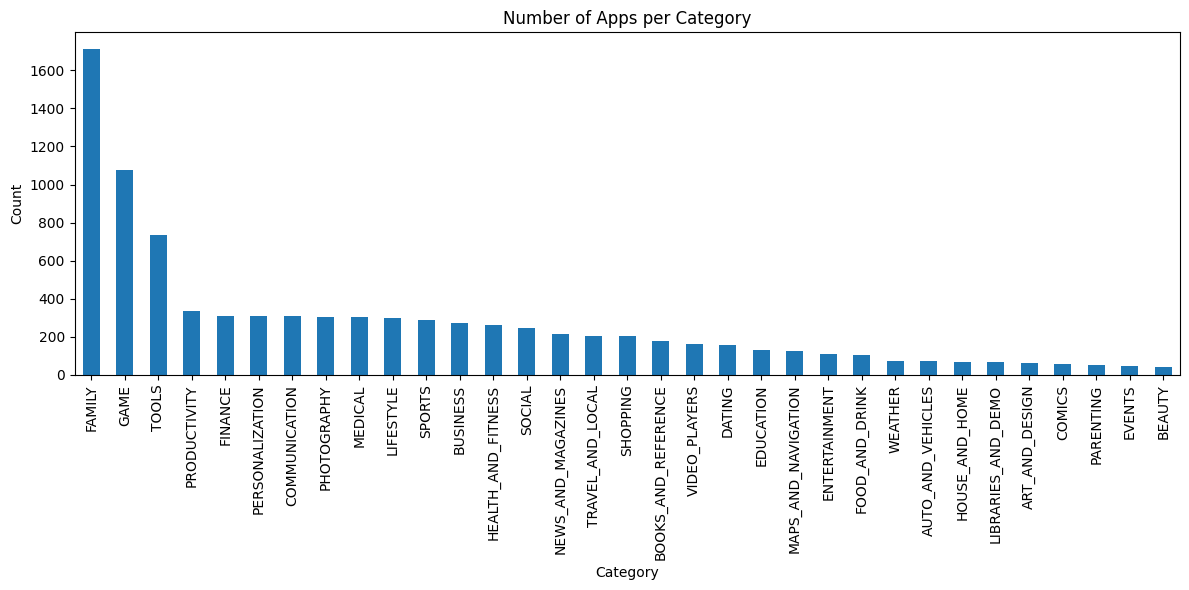

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title("Number of Apps per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


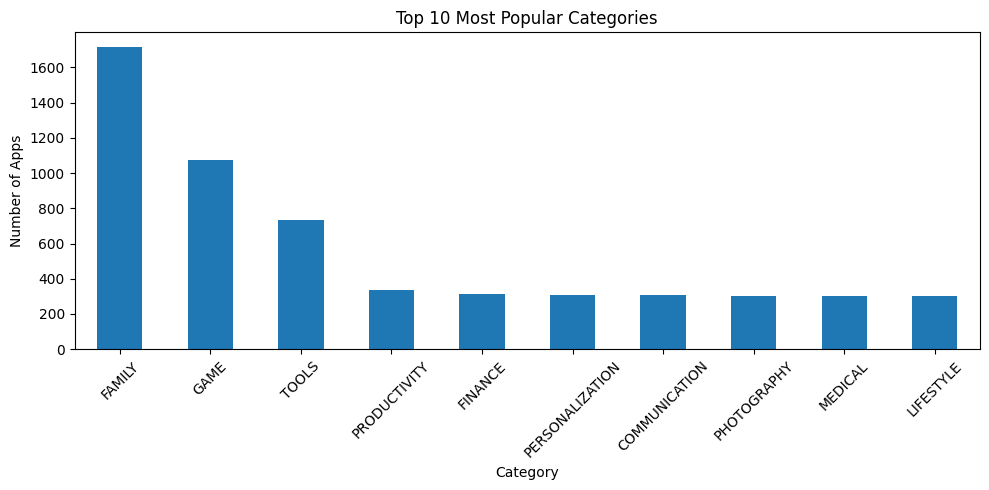

In [35]:
top10 = category_counts.head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind='bar')
plt.title("Top 10 Most Popular Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**B. Reviews vs Ratings:-**

This code examines the relationship between Reviews and Ratings.
First, it computes the correlation between the two numeric variables.
Then, it visualizes the trend using a scatter plot, where each point represents an app.

A log scale is applied to the Reviews axis to better display values that span a very wide range.
This helps determine whether apps with more reviews tend to receive higher ratings.

In [36]:
df_clean[['Reviews', 'Rating']].corr()


,Reviews,Rating
Reviews,1.000000,0.068616
Rating,0.068616,1.000000


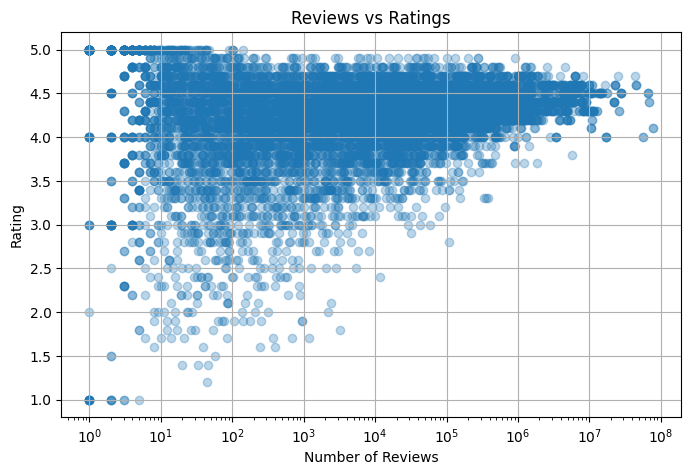

In [37]:
#Scatter Plot: Reviews vs Ratings
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Reviews'], df_clean['Rating'], alpha=0.3)
plt.title("Reviews vs Ratings")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.xscale('log')   # log scale helps because reviews vary widely
plt.grid(True)
plt.show()

**C. Free vs Paid Apps Analysis**

This code creates a bar chart to compare the number of Free and Paid apps in the dataset.
Using sns.countplot, it counts how many apps belong to each type and visualizes them side by side.
This helps us understand whether the Google Play Store is dominated by free apps or has a balanced mix of free and paid offerings.

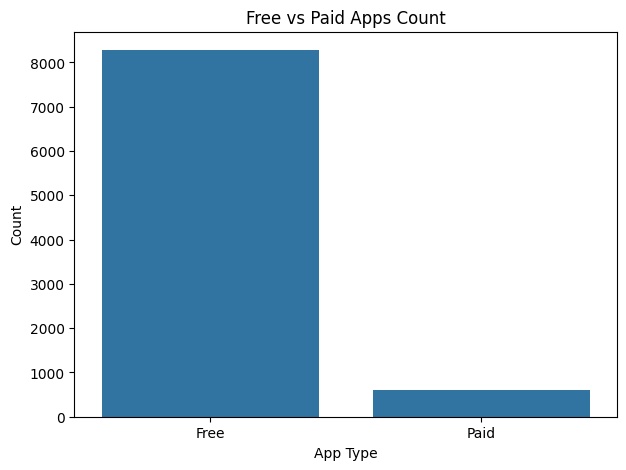

In [39]:
# Bar Chart: Count of Free vs Paid Apps
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='Type')
plt.title("Free vs Paid Apps Count")
plt.xlabel("App Type")
plt.ylabel("Count")
plt.show()

This code generates a boxplot to compare the rating distributions of Free and Paid apps.
Using sns.boxplot, it displays median, quartiles, and potential outliers for each type.
This visualization helps determine whether paid apps generally receive higher ratings or if both categories have similar rating patterns.

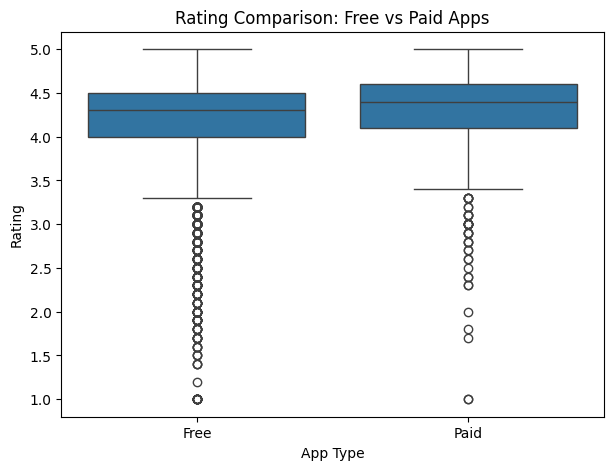

In [40]:
# Boxplot: Ratings of Free vs Paid Apps
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Type', y='Rating')
plt.title("Rating Comparison: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Rating")
plt.show()


This code analyzes the price distribution of paid apps by filtering only the apps labeled as “Paid.”
A histogram with a KDE curve is plotted to visualize how prices are spread, showing the most common price ranges and whether the distribution is skewed toward low or high prices.

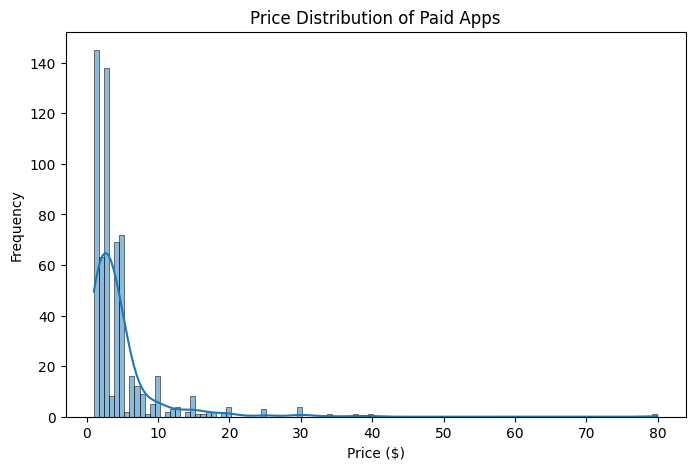

In [41]:
#Price Distribution (Paid Apps Only)
paid_apps = df_clean[df_clean['Type'] == 'Paid']

plt.figure(figsize=(8, 5))
sns.histplot(paid_apps['Price'], kde=True)
plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

**D. Rating Distribution**

This code visualizes the distribution of app ratings using a histogram.
It helps identify how ratings are spread across all apps—whether most apps have high ratings, low ratings, or if the distribution is skewed.
Grid lines improve readability, and 20 bins provide a detailed breakdown of rating frequencies.

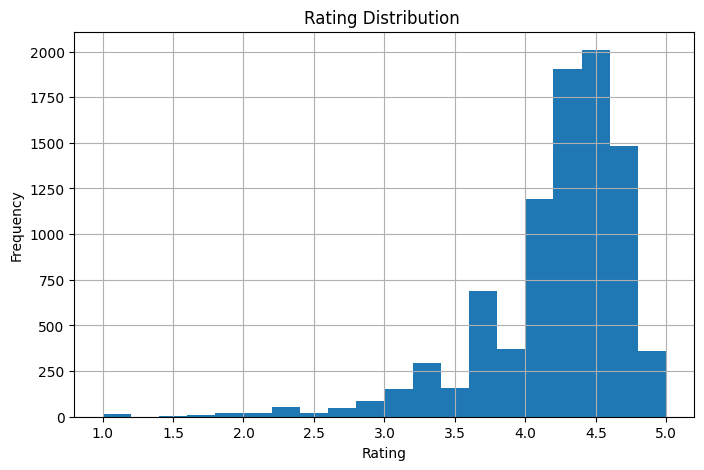

In [45]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Rating'], bins=20)
plt.title("Rating Distribution ")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


**E. Installs Analysis**

This code identifies and visualizes the Top 10 most installed apps in the dataset.
After sorting the apps by the number of installs in descending order, a horizontal bar chart is plotted.
The bars represent install counts, and the chart is inverted so that the highest-ranking apps appear at the top, making the visualization easier to interpret.

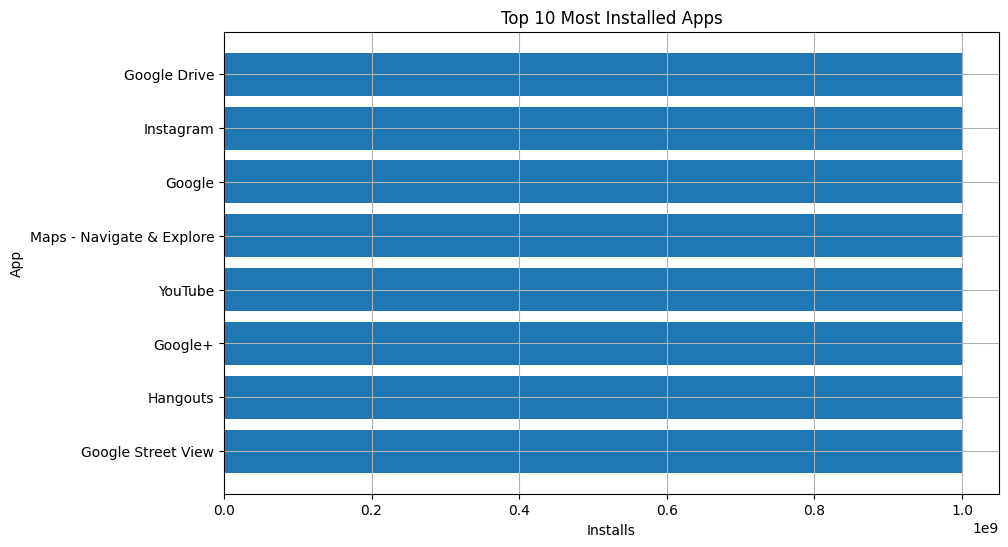

In [46]:
# Top 10 Apps by Installs
top10_installs = df_clean.sort_values(by="Installs", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_installs['App'], top10_installs['Installs'])
plt.title("Top 10 Most Installed Apps")
plt.xlabel("Installs")
plt.ylabel("App")
plt.gca().invert_yaxis()  # Highest at top
plt.grid(True)
plt.show()


This code calculates the total installs for each app category and visualizes them using a bar chart.
By grouping the dataset by Category and summing the number of installs, the plot reveals which categories attract the highest user downloads.
The bars are sorted in descending order, allowing easy comparison of category popularity.

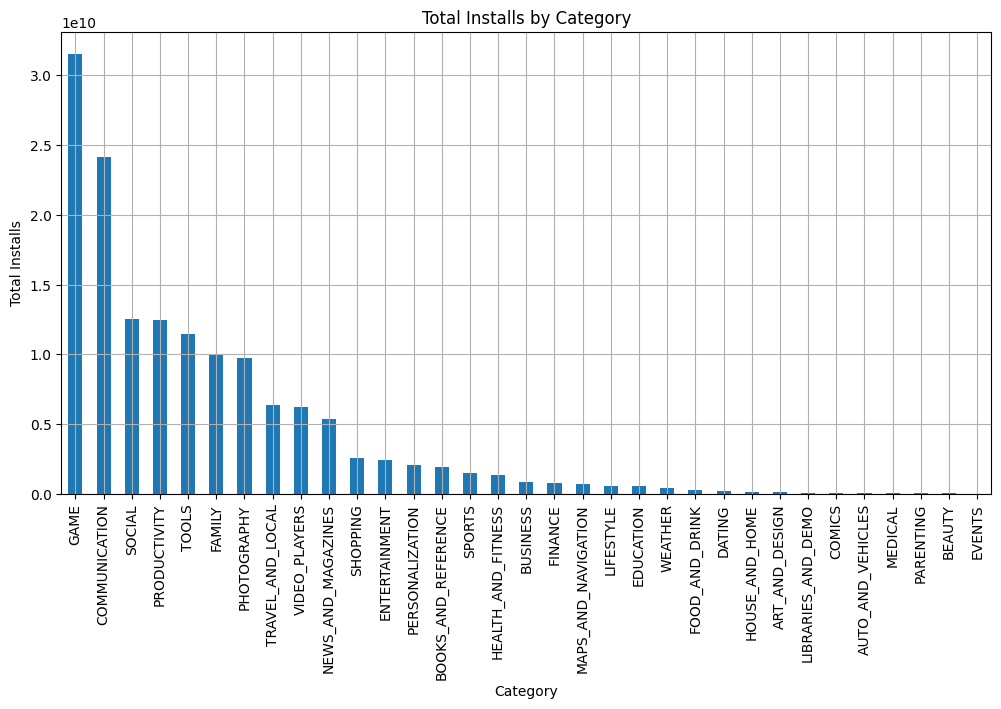

In [47]:
# Category vs Installs (Total Installs per Category)
category_installs = df_clean.groupby("Category")['Installs'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
category_installs.plot(kind='bar')
plt.title("Total Installs by Category")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


In [48]:
df_clean.groupby("Category")['Installs'].mean().sort_values(ascending=False).head(10)


,Installs
Category,
COMMUNICATION,7.867180e+07
SOCIAL,5.128624e+07
VIDEO_PLAYERS,3.888686e+07
PRODUCTIVITY,3.731458e+07
PHOTOGRAPHY,3.197777e+07
TRAVEL_AND_LOCAL,3.103346e+07
GAME,2.937045e+07
NEWS_AND_MAGAZINES,2.520145e+07
ENTERTAINMENT,2.212306e+07


**F. Correlation Heatmap**



This code selects only the numeric columns from the cleaned dataset and computes the correlation matrix.
The resulting corr_matrix shows the strength and direction of relationships between all numerical features in the dataset.
It helps identify which variables are positively or negatively correlated, which is useful for feature analysis, model building, and understanding data patterns.

In [49]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

corr_matrix


,Rating,Reviews,Size,Installs,Price,Log_Reviews,Category_App_Count,Category_Avg_Rating
Rating,1.000000,0.068616,0.066694,0.050727,0.020028,0.207378,0.013652,0.169760
Reviews,0.068616,1.000000,0.107565,0.633410,-0.025318,0.317050,0.010744,0.046156
Size,0.066694,0.107565,1.000000,0.046896,-0.001991,0.273079,0.284326,0.189341
Installs,0.050727,0.633410,0.046896,1.000000,-0.030681,0.334105,-0.029044,0.004853
Price,0.020028,-0.025318,-0.001991,-0.030681,1.000000,-0.110625,0.028016,0.000330
Log_Reviews,0.207378,0.317050,0.273079,0.334105,-0.110625,1.000000,0.006900,0.130311
Category_App_Count,0.013652,0.010744,0.284326,-0.029044,0.028016,0.006900,1.000000,0.080419
Category_Avg_Rating,0.169760,0.046156,0.189341,0.004853,0.000330,0.130311,0.080419,1.000000


The correlation heatmap provides a visual summary of the relationships between the numerical features in the dataset. Warmer colors (toward red) indicate strong positive correlations, while cooler colors (toward blue) represent strong negative correlations. This visualization helps reveal which factors move together. For example, features such as “Reviews,” “Installs,” and “Rating” can be compared to identify whether higher engagement leads to better ratings. The heatmap also helps detect multicollinearity, where two or more features are highly correlated, which is important for predictive modeling and understanding the overall structure of the dataset. Overall, it offers a clear and intuitive way to interpret the strength and direction of relationships between variables.

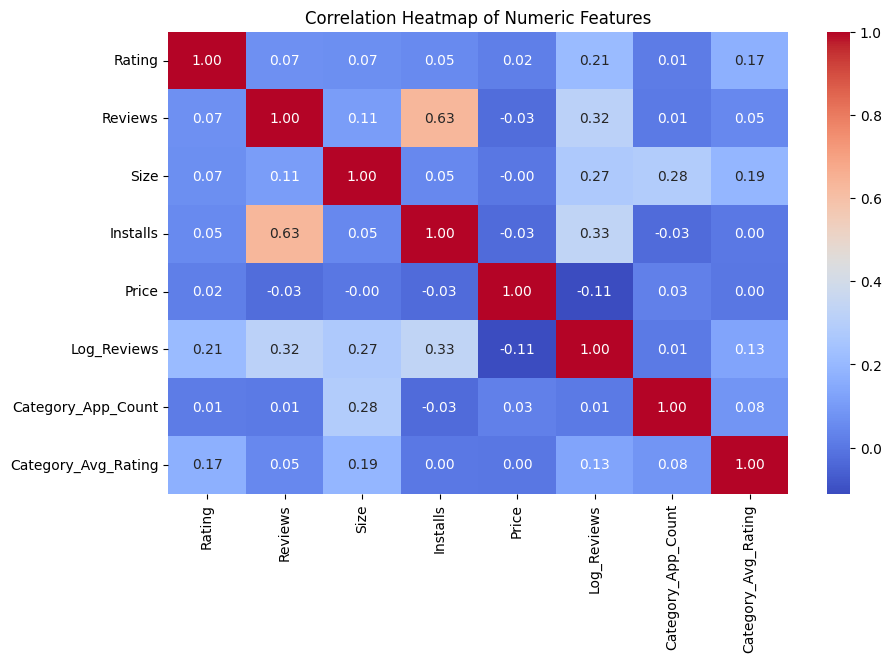

In [50]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


**6. Statistical Insights**

**Average Rating per Category:**
The point plot illustrates the average user rating for each app category, providing a clear comparison of how different types of apps are perceived by users. Each point represents the mean rating within a category, allowing trends to emerge—for example, categories with consistently higher ratings may indicate better user satisfaction, higher-quality apps, or stronger niche demand. Conversely, categories with lower average ratings may reflect greater variability in app quality or challenges inherent to that domain. This visualization helps identify which app categories maintain strong user approval and which may require further analysis or improvement.

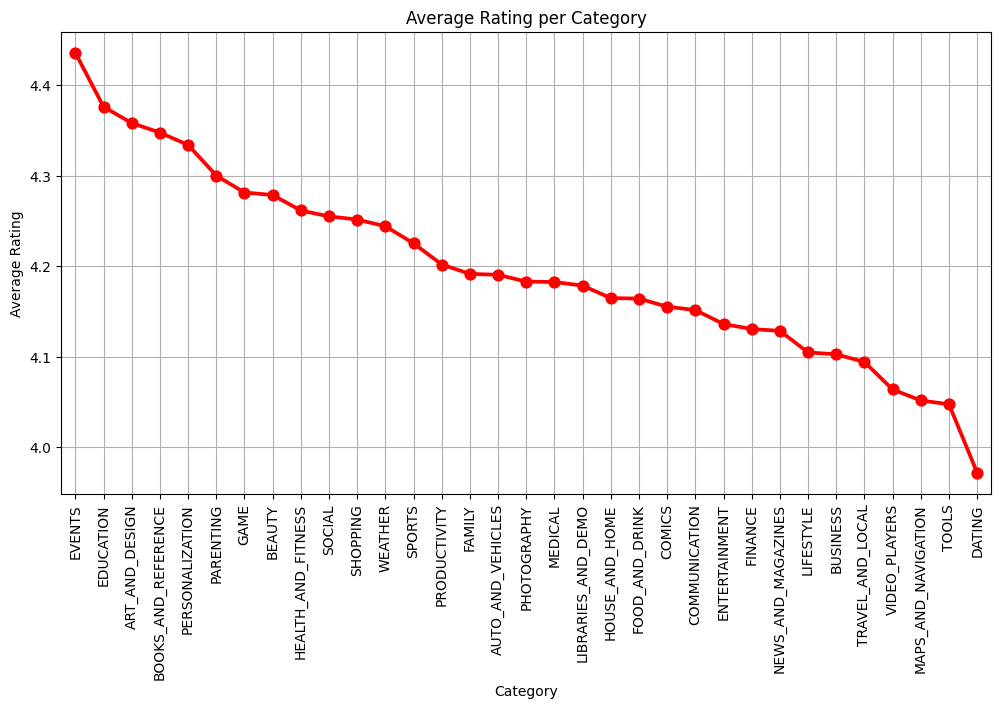

In [54]:
plt.figure(figsize=(12, 6))
sns.pointplot(
    x=avg_rating_category.index,
    y=avg_rating_category.values,
    color="red"
)
plt.title("Average Rating per Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


**Average Installs per Category**

The bar chart displays the average number of installs for each app category, offering insight into which categories attract the highest user engagement and popularity on the app store. Categories positioned at the top of the chart represent app types with consistently high download rates, indicating strong user demand or broad utility—such as communication, entertainment, or social-related apps. Meanwhile, categories lower on the scale reflect more specialized or niche markets with lower average install counts. This analysis helps highlight the competitive and widely-used app segments compared to those that appeal to a smaller audience, providing a better understanding of overall user behavior across categories.

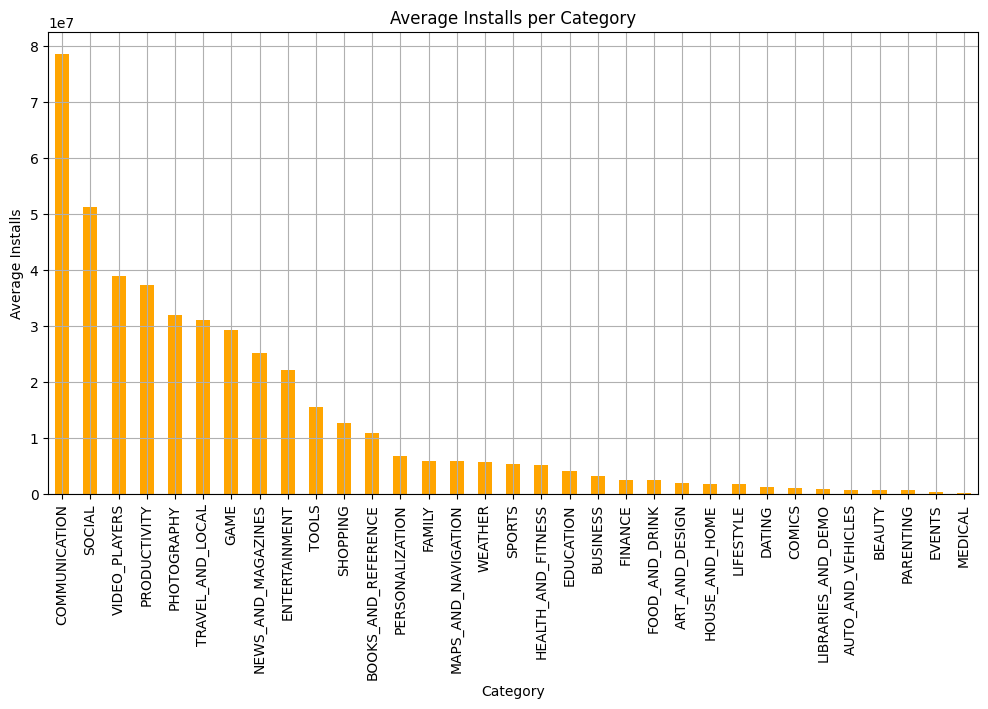

In [55]:
avg_installs_category = df_clean.groupby("Category")["Installs"].mean().sort_values(ascending=False)
avg_installs_category
plt.figure(figsize=(12, 6))
avg_installs_category.plot(kind='bar', color='orange')
plt.title("Average Installs per Category")
plt.xlabel("Category")
plt.ylabel("Average Installs")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


The final step saves the fully cleaned and processed dataset into a new CSV file named googleplaystore_cleaned.csv. By exporting the dataset without the index column, the file becomes ready for further analysis, visualization, or machine-learning tasks while maintaining a clean structure. This ensures that all missing values have been handled, data types have been standardized, and the dataset is now in an ideal format for future use or sharing.

In [56]:
df_clean.to_csv("googleplaystore_cleaned.csv", index=False)
print("Final cleaned dataset saved as googleplaystore_cleaned.csv")


Final cleaned dataset saved as googleplaystore_cleaned.csv


**Conclusion:-**

This project successfully performed a complete end-to-end data cleaning and exploratory analysis of the Google Play Store dataset. Through systematic handling of missing values, conversion of inconsistent data formats, removal of invalid entries, and transformation of key fields such as Size, Installs, and Price, the dataset was standardized for reliable analysis. Comprehensive visualizations and statistical summaries provided insights into app categories, user ratings, pricing patterns, installs, and feature correlations. The cleaned dataset was finally exported as googleplaystore_cleaned.csv, making it fully prepared for advanced analytics, predictive modeling, or machine-learning applications. Overall, this project establishes a strong foundation for deeper insights into mobile app market trends and supports future data-driven decision-making.